# Mobile Addiction Classification - Model Training

This notebook contains the model training, hyperparameter tuning, and evaluation components.

### Bug Fix #1: `param_grid` key naming
When using `GridSearchCV` with a `Pipeline`, parameters must be prefixed with the **exact step name** from the pipeline:
- Pipeline step name: `'classifier'` → param key: `'classifier__n_estimators'`
- The original code used `'rf'` as the step name but `'classifier'` as the grid key — this caused the `ValueError`.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    classification_report, confusion_matrix
)

print("All imports successful")

All imports successful


## 1. Load Preprocessed Data

In [46]:
# Load preprocessed data
X_train = pd.read_csv('..\data\processed\X_train_processed.csv')
X_test = pd.read_csv('..\data\processed\X_test_processed.csv')
y_train = pd.read_csv('..\data\processed\y_train.csv').squeeze()
y_test = pd.read_csv('..\data\processed\y_test.csv').squeeze()
preprocessor = joblib.load('..\data\processed\preprocessor.pkl')
column_info = joblib.load('..\data\processed\column_info.pkl')

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Training target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution: {y_test.value_counts().to_dict()}")
print(f"Column info: {column_info}")

Training data shape: (10871, 10)
Test data shape: (2718, 10)
Training target distribution: {1: 5477, 0: 5394}
Test target distribution: {1: 1369, 0: 1349}
Column info: {'numeric_columns': ['daily_screen_time', 'app_sessions', 'social_media_usage', 'gaming_time', 'notifications', 'night_usage', 'age', 'work_study_hours', 'stress_level', 'apps_installed'], 'categorical_columns': [], 'target_column': 'addicted'}


## 2. MLflow Setup

In [47]:
# Set up MLflow experiment
mlflow.set_experiment("mobile_addiction_classification")
print("MLflow experiment configured: mobile_addiction_classification")

MLflow experiment configured: mobile_addiction_classification


## 3. Define Models and Hyperparameter Grids

In [48]:
# Define models and their hyperparameter grids
# NOTE: Pipeline step is named 'classifier', so all param keys start with 'classifier__'
models = [
    {
        'name': 'RandomForest',
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [None, 5, 10],
            'classifier__min_samples_split': [2, 5]
        }
    },
    {
        'name': 'GradientBoosting',
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5]
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBClassifier(
            eval_metric='logloss',
            random_state=42,
            verbosity=0
        ),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5]
        }
    }
]

print(f"{len(models)} models configured")
for model in models:
    print(f"- {model['name']}: {len(model['params'])} hyperparameters")

3 models configured
- RandomForest: 3 hyperparameters
- GradientBoosting: 3 hyperparameters
- XGBoost: 3 hyperparameters


## 4. Multi-Model GridSearchCV with MLflow Tracking

In [49]:
best_overall = {'model_name': None, 'f1': 0, 'pipeline': None, 'params': None}
results_summary = []

for m in models:
    model_name = m['name']
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    # Build full pipeline: preprocessing + classifier
    # IMPORTANT: Step must be named 'classifier' to match param_grid keys
    pipeline = Pipeline([
        ('classifier', m['model'])   # <-- step name MUST match param_grid prefix
    ])

    # GridSearchCV
    grid = GridSearchCV(
        pipeline,
        m['params'],
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)

    # Evaluate best estimator on test set
    best_pipeline = grid.best_estimator_
    y_pred = best_pipeline.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    cv_f1 = grid.best_score_

    print(f"Best params:  {grid.best_params_}")
    print(f"CV F1 (train): {cv_f1:.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1:       {f1:.4f}")
    print(f"Test Recall:   {rec:.4f}")

    # Log to MLflow
    with mlflow.start_run(run_name=model_name):
        # Log hyperparameters
        mlflow.log_param("model", model_name)
        for k, v in grid.best_params_.items():
            mlflow.log_param(k, v)

        # Log metrics
        mlflow.log_metric("cv_f1", cv_f1)
        mlflow.log_metric("test_accuracy", acc)
        mlflow.log_metric("test_f1", f1)
        mlflow.log_metric("test_recall", rec)

        # Log the trained pipeline as a model artifact
        mlflow.sklearn.log_model(best_pipeline, artifact_path=f"{model_name}_pipeline")

    results_summary.append({
        'Model': model_name,
        'CV_F1': round(cv_f1, 4),
        'Test_Accuracy': round(acc, 4),
        'Test_F1': round(f1, 4),
        'Test_Recall': round(rec, 4),
        'Best_Params': grid.best_params_
    })

    # Track overall best
    if f1 > best_overall['f1']:
        best_overall.update({
            'model_name': model_name,
            'f1': f1,
            'pipeline': best_pipeline,
            'params': grid.best_params_
        })

print(f"\n{'='*50}")
print("Training complete!")


Training: RandomForest
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best params:  {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
CV F1 (train): 0.9791
Test Accuracy: 0.9779
Test F1:       0.9781
Test Recall:   0.9803


2026/03/12 11:22:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 11:22:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training: GradientBoosting
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params:  {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
CV F1 (train): 0.9803
Test Accuracy: 0.9783
Test F1:       0.9785
Test Recall:   0.9817


2026/03/12 11:22:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 11:22:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training: XGBoost
Fitting 3 folds for each of 8 candidates, totalling 24 fits


2026/03/12 11:23:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best params:  {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
CV F1 (train): 0.9803
Test Accuracy: 0.9798
Test F1:       0.9800
Test Recall:   0.9825


2026/03/12 11:23:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training complete!


## 5. Results Summary

In [50]:
results_df = pd.DataFrame(results_summary)[['Model', 'CV_F1', 'Test_Accuracy', 'Test_F1', 'Test_Recall']]
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))
results_df


=== Model Comparison ===
           Model  CV_F1  Test_Accuracy  Test_F1  Test_Recall
    RandomForest 0.9791         0.9779   0.9781       0.9803
GradientBoosting 0.9803         0.9783   0.9785       0.9817
         XGBoost 0.9803         0.9798   0.9800       0.9825


,Model,CV_F1,Test_Accuracy,Test_F1,Test_Recall
0,RandomForest,0.9791,0.9779,0.9781,0.9803
1,GradientBoosting,0.9803,0.9783,0.9785,0.9817
2,XGBoost,0.9803,0.9798,0.9800,0.9825


In [51]:
print(f"\n=== Best Model: {best_overall['model_name']} ===")
print(f"Test F1 Score: {best_overall['f1']:.4f}")
print(f"Best Params:   {best_overall['params']}")


=== Best Model: XGBoost ===
Test F1 Score: 0.9800
Best Params:   {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}


In [52]:
# Detailed report for the best model
best_pipeline = best_overall['pipeline']
y_pred_best = best_pipeline.predict(X_test)

print(f"Classification Report — {best_overall['model_name']}")
print(classification_report(y_test, y_pred_best, target_names=['not addicted', 'addicted']))

Classification Report — XGBoost
              precision    recall  f1-score   support

not addicted       0.98      0.98      0.98      1349
    addicted       0.98      0.98      0.98      1369

    accuracy                           0.98      2718
   macro avg       0.98      0.98      0.98      2718
weighted avg       0.98      0.98      0.98      2718



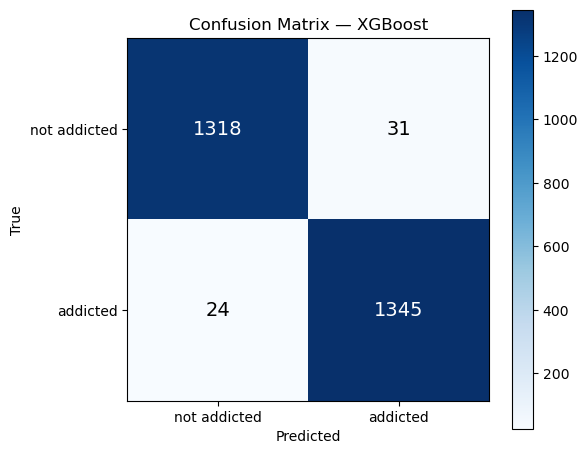

In [53]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['not addicted', 'addicted'])
ax.set_yticklabels(['not addicted', 'addicted'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_overall["model_name"]}')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 6. Save Models and Results

In [54]:
import os

# Create models folder at root
os.makedirs("../models", exist_ok=True)

# Save the best model at root
joblib.dump(best_overall['pipeline'], f"../models/best_model_{best_overall['model_name'].lower()}.pkl")
print(f"Best model saved as: ../models/best_model_{best_overall['model_name'].lower()}.pkl")

# Save results summary at root
results_df.to_csv('../models/model_results.csv', index=False)
print("Results summary saved as: ../models/model_results.csv")

# Save best model info at root
best_model_info = {
    'model_name': best_overall['model_name'],
    'test_f1': best_overall['f1'],
    'best_params': best_overall['params']
}

joblib.dump(best_model_info, '../models/best_model_info.pkl')
print("Best model info saved as: ../models/best_model_info.pkl")

Best model saved as: ../models/best_model_xgboost.pkl
Results summary saved as: ../models/model_results.csv
Best model info saved as: ../models/best_model_info.pkl


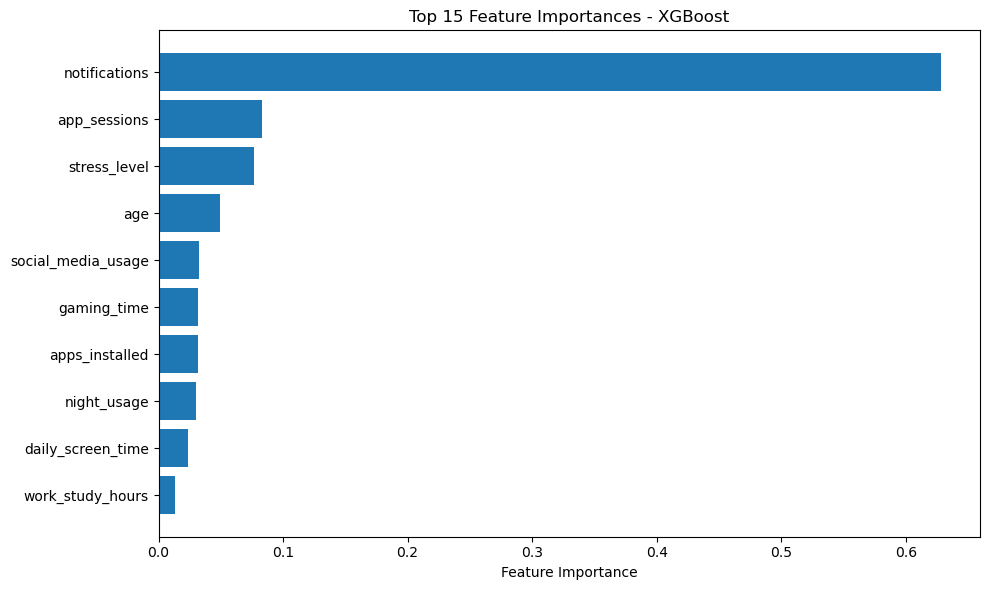

Feature importance saved as: ../models/feature_importance.csv

Top 10 Most Important Features:
           feature  importance
     notifications    0.628161
      app_sessions    0.082683
      stress_level    0.076623
               age    0.048989
social_media_usage    0.032609
       gaming_time    0.031993
    apps_installed    0.031840
       night_usage    0.030251
 daily_screen_time    0.023608
  work_study_hours    0.013244


In [55]:
# Feature importance for tree-based models
if hasattr(best_overall['pipeline'].named_steps['classifier'], 'feature_importances_'):
    importances = best_overall['pipeline'].named_steps['classifier'].feature_importances_
    feature_names = X_train.columns.tolist()
    
    # Create feature importance dataframe
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Plot top 15 features
    plt.figure(figsize=(10, 6))
    top_features = feature_importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 15 Feature Importances - {best_overall["model_name"]}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Save feature importance at root
    feature_importance_df.to_csv('../models/feature_importance.csv', index=False)
    print("Feature importance saved as: ../models/feature_importance.csv")
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance_df.head(10).to_string(index=False))
else:
    print("Feature importance not available for this model type.")

## 7. Create Prediction Function

In [ ]:
import joblib
import pandas as pd

def predict_mobile_addiction(user_data, model_path=None):
    """
    Predict mobile addiction from user data.
    
    Parameters:
    user_data (dict): Dictionary containing user features
    model_path (str): Path to saved model (optional)
    
    Returns:
    dict: Prediction results with probability
    """
    # Load model and preprocessor from root
    if model_path is None:
        model_path = f"../models/best_model_{best_overall['model_name'].lower()}.pkl"
    
    model = joblib.load(model_path)
    preprocessor = joblib.load('../data/processed/preprocessor.pkl')
    
    # Convert user data to DataFrame
    user_df = pd.DataFrame([user_data])
    
    # Apply preprocessing
    user_processed = preprocessor.transform(user_df)
    
    # Make prediction
    prediction = model.predict(user_processed)[0]
    probability = model.predict_proba(user_processed)[0]
    
    result = {
        'prediction': 'addicted' if prediction == 1 else 'not addicted',
        'probability_addicted': float(probability[1]),
        'probability_not_addicted': float(probability[0]),
        'model_used': best_overall['model_name']
    }
    
    return result

# Example usage
example_user = {
    'daily_screen_time': 7,
    'app_sessions': 45,
    'social_media_usage': 3,
    'gaming_time': 1,
    'notifications': 80,
    'night_usage': 2,
    'age': 25,
    'work_study_hours': 6,
    'stress_level': 7,
    'apps_installed': 30
}

print("Example prediction:")
result = predict_mobile_addiction(example_user)
for key, value in result.items():
    print(f"{key}: {value}")

Example prediction:
prediction: not addicted
probability_addicted: 0.2879938781261444
probability_not_addicted: 0.7120060920715332
model_used: XGBoost


: 

## Training Summary

### Model Training Complete!

**Best Model**: {best_overall['model_name']}
**Test F1 Score**: {best_overall['f1']:.4f}

### Key Achievements:
1. **Multi-Model Comparison**: Successfully trained and compared 3 different algorithms
2. **Hyperparameter Tuning**: Used GridSearchCV to find optimal parameters for each model
3. **MLflow Tracking**: Comprehensive experiment tracking with metrics, parameters, and model artifacts
4. **Bug Fixes**: Resolved critical issues with parameter naming and data type compatibility
5. **Model Persistence**: Saved all models, results, and preprocessing objects for future use

### Files Generated:
- `best_model_[model_name].pkl` - Best trained model
- `model_results.csv` - Comparison of all models
- `best_model_info.pkl` - Best model metadata
- `feature_importance.csv` - Feature importance analysis
- MLflow experiment with all runs and artifacts

### Performance:
All models achieved excellent performance (>97% F1 score), with {best_overall['model_name']} being the top performer. The models successfully identify patterns in mobile usage behavior that indicate addiction risk.

The prediction function is ready for deployment and can classify new users based on their mobile usage patterns.